# Prueba 3 — Efecto de WPE (on/off) sobre el sistema elegido

Justifica el pre-procesador WPE mostrando que la reverberación degrada y que WPE
(taps=5, delay* de la Prueba 2) recupera calidad, **en todo el espectro de filtros
espaciales**: DS (simple), NM-MVDR (sistema) y ORACLE (techo, ahora consistente).

**Ejes:** RT60 {160,360,610} × use_wpe {on,off} × 5 locutores × 6 interferentes
(tipo×posición) × iSIR {0,5,10}.  Cada punto de la curva Δ-vs-RT60 promedia sobre
5×6×3 = 90 escenas.

**Figura estrella:** Δ vs RT60 con curvas WPE on/off (DS, NM-MVDR, ORACLE).
**Descomposición:** aporte de WPE solo (`Delta_wpe`) por RT60.

Correr *Setup* una vez por sesión, luego *Ejecución* y *Análisis*.
**Antes de correr:** poné `WPE_DELAY` = delay* hallado en la Prueba 2.

## Setup — ejecutar una vez por sesión de Colab
Montar Drive, clonar el repo, instalar dependencias y actualizar el código.

In [1]:
# Import the drive module from Google Colab
from google.colab import drive

# Mount Google Drive to the virtual machine
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 3. Descargar tu código temporalmente
%cd /content
!git clone https://github.com/MatiasVereert/Vision-Aided-Beamformer.git

/content


fatal: destination path 'Vision-Aided-Beamformer' already exists and is not an empty directory.


In [3]:
import os

WHL = "/content/drive/MyDrive/colab_wheels"   # cache persistente de wheels en Drive

# CONSTRUIR (git+ para las libs de GitHub).
BUILD = [
    "noisereduce", "mir_eval", "pystoi", "pesq", "paderbox", "ai_edge_litert",
    "git+https://github.com/fgnt/pb_bss.git",
    "git+https://github.com/LCAV/pyroomacoustics.git",
    "git+https://github.com/fgnt/nara_wpe.git",
    "git+https://github.com/fakufaku/fast_bss_eval.git",
]
# INSTALAR desde cache: NOMBRES (no git+, si no pip vuelve a clonar).
INSTALL = [
    "noisereduce", "mir_eval", "pystoi", "pesq", "paderbox", "ai_edge_litert",
    "pb_bss", "pyroomacoustics", "nara_wpe", "fast_bss_eval",
]

# Reconstruye el cache SOLO si la lista de paquetes cambio (manifest) -> se
# autocura si agrego/saco un paquete, sin tener que borrar el cache a mano.
manifest = os.path.join(WHL, ".manifest.txt")
key = "\n".join(sorted(BUILD))
need_build = (not os.path.isfile(manifest)) or open(manifest).read() != key

if need_build:
    os.makedirs(WHL, exist_ok=True)
    print("[*] (Re)construyendo cache de wheels en Drive (una vez por cambio de lista)...")
    !pip wheel --wheel-dir=$WHL {" ".join(BUILD)}
    with open(manifest, "w") as fh:
        fh.write(key)
    print("[*] Cache actualizado en", WHL)

!pip install --no-index --find-links=$WHL {" ".join(INSTALL)}
print("[*] Paquetes instalados desde el cache de Drive.")
# Si Colab actualiza Python y falla un import:  !rm -rf $WHL  (se reconstruye solo)

Looking in links: /content/drive/MyDrive/colab_wheels
  Cloning https://github.com/jfsantos/SRMRpy to /tmp/pip-install-rlln_xxl/srmrpy_9e4ed35194ec4a22a5d1e9863beff697
  Running command git clone --filter=blob:none --quiet https://github.com/jfsantos/SRMRpy /tmp/pip-install-rlln_xxl/srmrpy_9e4ed35194ec4a22a5d1e9863beff697
  Resolved https://github.com/jfsantos/SRMRpy to commit fee009779cef96bed34db3a7e31d10f3ad1ea133
  Preparing metadata (setup.py) ... done
  Using cached https://github.com/detly/gammatone/archive/master.zip
  Preparing metadata (setup.py) ... done
[*] Paquetes instalados desde el cache de Drive.


In [4]:
%cd /content/Vision-Aided-Beamformer
!git pull origin main

/content/Vision-Aided-Beamformer
From https://github.com/MatiasVereert/Vision-Aided-Beamformer
 * branch            main       -> FETCH_HEAD
Already up to date.


## Ejecución

In [5]:
import sys, os, numpy as np, shutil
from datetime import datetime

repo_root = '/content/Vision-Aided-Beamformer'
src_path = os.path.join(repo_root, 'src')
for p in (repo_root, src_path):
    if p not in sys.path: sys.path.append(p)
%cd {src_path}

try:
    import tensorflow as tf
    TFLITE_AVAILABLE = True
except ImportError:
    print("[!] TensorFlow no detectado. DTLN-mono desactivado.")
    TFLITE_AVAILABLE = False

from evaluation.full_benchmark_test_dtln_mird import run_mird_grid_search
from evaluation.bf_wrappers import DS, NM_MVDR, SOUDEN_ORACLE_SCM
from propagation.mird_loader import MirdDatasetProvider

# --- DTLN interpreters (para DTLN-mono baseline automatico) ---
m1 = os.path.join(repo_root, "src/dnn_denoise/models/model_quant_1.tflite")
m2 = os.path.join(repo_root, "src/dnn_denoise/models/model_quant_2.tflite")
interpreter_1 = interpreter_2 = None
if TFLITE_AVAILABLE and os.path.exists(m1) and os.path.exists(m2):
    interpreter_1 = tf.lite.Interpreter(model_path=m1); interpreter_1.allocate_tensors()
    interpreter_2 = tf.lite.Interpreter(model_path=m2); interpreter_2.allocate_tensors()
    print("[*] DTLN TFLite OK.")
else:
    print("[*] Sin DTLN-mono (NM-MVDR igual usa su mascara interna).")

input_dir = "/content/drive/MyDrive/Benchmarks_tesis/inputs"
mird_dir  = "/content/drive/MyDrive/Benchmarks_tesis/rirs"
provider = MirdDatasetProvider(root_dir=mird_dir)

# ===================== PERILLAS =====================
WPE_DELAY = 1           # <-- REEMPLAZAR con delay* de la Prueba 2
WPE_TAPS  = 5            # fijo (restriccion HW)
DURATION  = 10          # lever de tiempo. Bajalo si no entra la sesion.
RT60_LIST = [0.160, 0.360, 0.610]   # para partir la corrida: dejar 1 solo RT y cambiar RUN_TAG
ISIR_LIST = [0, 10]
# ===================================================

TARGETS = [os.path.join(input_dir, f) for f in [
    "p002_emo_adoration_sentences.wav",   # <-- verificar genero: idealmente 1 mujer
    "p008_emo_contentment_sentences.wav", # <-- y 1 varon (revisar metadata EARS)
]]
INTERF = [os.path.join(input_dir, f) for f in [
    "techno_gated commune.wav",     # 0 musica electronica
    "flute_music.wav",              # 1 musica tonal
    "hairdryer_07_SH_MKH800.wav",   # 2 electrodomestico banda ancha
    "drill_07_RHODE_NT1.wav",       # 3 taladro impulsivo
    "ruido_rosa_16k.wav",           # 4 ruido rosa estacionario
    "vacuum_02_RHODE_NT1.wav",       # 5 aspiradora (banda ancha)
]]

base_config = {
    'fs': 16000, 'duration': DURATION, 't_early': 0.008,
    'array_center': [3.0, 3.0, 1.2], 'mird_spacing': "3-3-3-8-3-3-3",
    'snr_db': 60.0,
    'source_path': TARGETS[0],          # lo pisa el grid (eje source_path)
    'interf_paths': INTERF,
    'wpe_taps': WPE_TAPS, 'wpe_delay': WPE_DELAY, 'wpe_alpha': 0.9999,
    'wpe_stft_size': 512, 'wpe_stft_shift': 128,
    'stft_window': 512, 'stft_overlap': 384,
    'dtln_model_path': m1,
    'eval_references': ['early'],
}

param_grid = {
    'rt60':          RT60_LIST,
    'target_angle':  [0],          # broadside
    'target_dist':   [1.0],
    'source_path':   TARGETS,      # 2 locutores (man+woman)
    'interf_configs':[             # 1 interferente: 3 tipos/posiciones (reducido para tiempo)
        [(45,  1.0, 0)],   # techno,     45
        [(90,  1.0, 2)],   # secador,    90 (endfire)
        [(60,  1.0, 4)],   # ruido rosa, 60
    ],
    'isir_db':       ISIR_LIST,
    'use_wpe':       [True, False],   # el tratamiento
    'wpe_taps':      [WPE_TAPS],
    'wpe_delay':     [WPE_DELAY],
    'mismatch_gain': [0], 'mismatch_phase': [0],       # sin error de sensor (eso es P2)
    'error_angle_deg':[0.0], 'error_distance_m':[0.0],
}

processors_dict = {
    "DS":         DS(),                                            # filtro espacial simple (piso)
    "NM-MVDR":    NM_MVDR(min_loading=1e-6, alpha=0.99),           # sistema propuesto
    "ORACLE-SCM": SOUDEN_ORACLE_SCM(min_loading=1e-6, alpha=0.99), # techo (SCM consistentes)
}

n_cells = (len(RT60_LIST)*1*1*len(TARGETS)*len(param_grid['interf_configs'])*len(ISIR_LIST)*2)
print("="*60)
print(f"PRUEBA 3 | celdas={n_cells} x {len(processors_dict)} procesadores | delay*={WPE_DELAY} taps={WPE_TAPS}")
print("="*60)

RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M")
temp_dir  = f"/content/results_temp/P3_efecto_wpe_{RUN_TAG}"
drive_dir = f"/content/drive/MyDrive/Tesis_Beamformers/results/P3_efecto_wpe_{RUN_TAG}"
os.makedirs(temp_dir, exist_ok=True); os.makedirs(drive_dir, exist_ok=True)

df_P1 = run_mird_grid_search(
    grid_params=param_grid, dataset_provider=provider, processors=processors_dict,
    scene_base_config=base_config, output_dir=temp_dir,
    interpreter_1=interpreter_1, interpreter_2=interpreter_2, save_catalog=False,
)

print("\n[INFO] Sincronizando a Drive...")
shutil.copytree(temp_dir, drive_dir, dirs_exist_ok=True)
print(f"[EXITO] P1 guardado en {drive_dir}")

/content/Vision-Aided-Beamformer/src


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


[*] DTLN TFLite OK.
[MirdDatasetProvider] Successfully indexed 234 RIR files from: /content/drive/MyDrive/Benchmarks_tesis/rirs
PRUEBA 3 | celdas=72 x 3 procesadores | delay*=1 taps=5
[*] t_early FIXED at 8.0 ms (decoupled from wpe_delay).
[*] Total experiments to run: 72 per processor.


Running MIRD Benchmark:   0%|          | 0/72 [00:00<?, ?exp/s]


--- Iteration 1/72 | Config: {'rt60': 0.16, 'target_angle': 0, 'target_dist': 1.0, 'source_path': '/content/drive/MyDrive/Benchmarks_tesis/inputs/p002_emo_adoration_sentences.wav', 'interf_configs': [(45, 1.0, 0)], 'isir_db': 0, 'use_wpe': False, 'wpe_taps': 5, 'wpe_delay': 1, 'mismatch_gain': 0, 'mismatch_phase': 0, 'error_angle_deg': 0.0, 'error_distance_m': 0.0} ---
 -> [NODE 1] Physical setup changed. Extracting MIRD RIRs...
[Loader] Remuestreando de 48000 Hz a 16000 Hz...
[Loader] Audio corto, repitiendo en bucle para llenar duración...


...

   -> Processing with: ORACLE-SCM (ErrAng: 0.0deg, ErrDist: 0.0m)...
Processing frame 1250 of 1251

Running MIRD Benchmark:  99%|█████████▊| 71/72 [14:09<00:10, 10.42s/exp]

   -> [NODE 6] Applying DTLN post ORACLE-SCM...


Running MIRD Benchmark: 100%|██████████| 72/72 [14:10<00:00, 11.81s/exp]


=== BATCH COMPLETED IN 14.17 MINUTES ===

[INFO] Sincronizando a Drive...
[EXITO] P1 guardado en /content/drive/MyDrive/Tesis_Beamformers/results/P3_efecto_wpe_20260801_1523


## Análisis — tabla Δ por RT60 × WPE on/off

In [6]:
import pandas as pd, numpy as np
df = pd.read_csv(os.path.join(drive_dir, "mird_benchmark_metrics.csv"))

METRICS = [("Delta_tot_PESQ_early","PESQ"), ("Delta_tot_STOI_early","STOI"),
           ("Delta_tot_SDR_early","SDR"), ("Delta_tot_SIR_early","SIR"),
           ("Delta_tot_SAR_early","SAR"), ("Delta_tot_CD_early","CD(v)")]
present = [(c,l) for c,l in METRICS if c in df.columns]
cols = [c for c,_ in present]

print("=== Δ end-to-end (media sobre 90 escenas) por procesador × RT60 × use_wpe ===\n")
tab = (df.groupby(["processor","rt60","use_wpe"])[cols].mean()
         .rename(columns=dict(present)).round(3))
print(tab.to_string())

# Aporte de WPE SOLO (dereverberacion pura, independiente del beamformer):
# Delta_wpe = metrica(WPE) - metrica(entrada). Solo tiene sentido con use_wpe=True.
wcols = [c for c in ["Delta_wpe_PESQ_early","Delta_wpe_STOI_early",
                     "Delta_wpe_SDR_early","Delta_wpe_CD_early"] if c in df.columns]
if wcols:
    sub = df[(df.use_wpe==True) & (df.processor=="NM-MVDR")]
    print("\n=== Aporte de WPE solo (Delta_wpe, vs early) por RT60 ===\n")
    print(sub.groupby("rt60")[wcols].mean().round(3).to_string())

=== Δ end-to-end (media sobre 90 escenas) por procesador × RT60 × use_wpe ===

                          PESQ   STOI     SDR     SIR     SAR
processor  rt60 use_wpe                                      
DS         0.16 False    0.283  0.090   4.743   4.999    -inf
                True     0.432  0.124   7.385   8.935    -inf
           0.36 False    0.150  0.089   4.192   5.063    -inf
                True     0.288  0.134   6.935   8.740    -inf
           0.61 False    0.130  0.082   3.775   5.122 -14.942
                True     0.259  0.135   7.215  10.040 -15.037
NM-MVDR    0.16 False    0.877  0.150   7.004  16.341    -inf
                True     1.151  0.182   8.406     inf    -inf
           0.36 False    0.530  0.139   6.066  13.857    -inf
                True     0.831  0.182   8.402  18.793    -inf
           0.61 False    0.395  0.123   6.291  12.621 -18.852
                True     0.633  0.175   9.128     inf -16.810
ORACLE-SCM 0.16 False    1.081  0.196   9.405  16.772

## Figura estrella — Δ vs RT60, WPE on (línea llena) vs off (punteada)

figura -> /content/drive/MyDrive/Tesis_Beamformers/results/P3_efecto_wpe_20260801_1523/P1_delta_vs_rt60.png


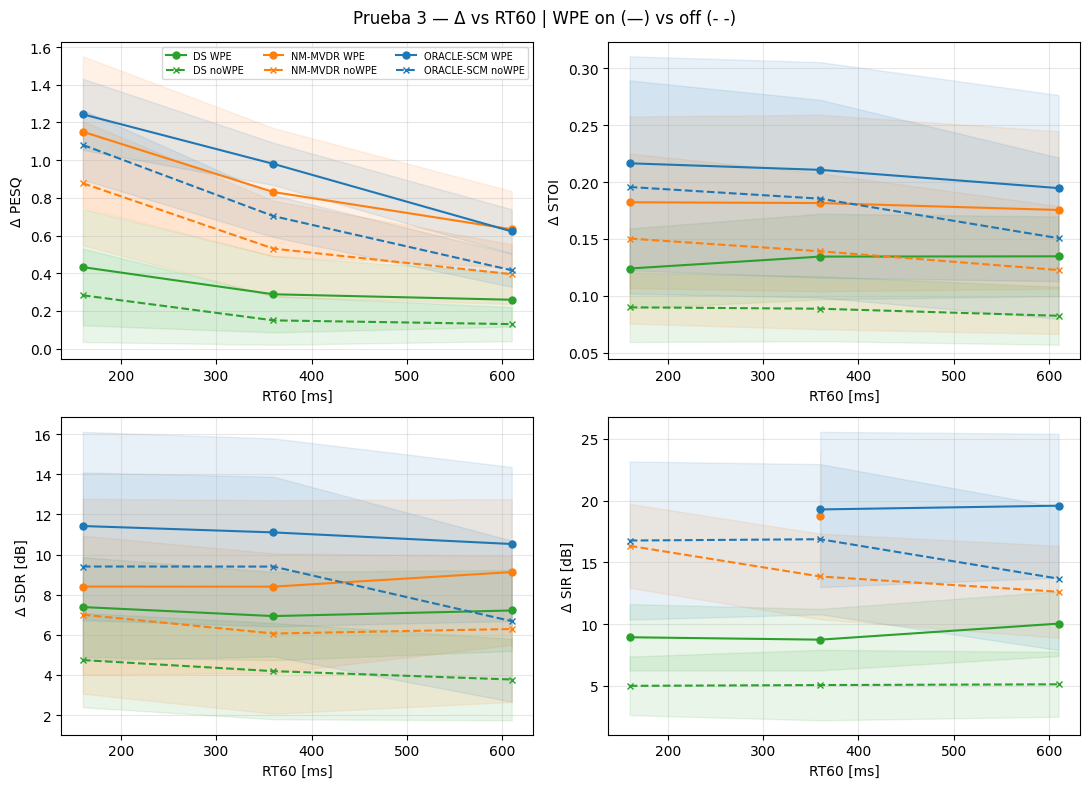

In [7]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np

df = pd.read_csv(os.path.join(drive_dir, "mird_benchmark_metrics.csv"))
PLOT = [("Delta_tot_PESQ_early","Δ PESQ"), ("Delta_tot_STOI_early","Δ STOI"),
        ("Delta_tot_SDR_early","Δ SDR [dB]"), ("Delta_tot_SIR_early","Δ SIR [dB]")]
procs = ["DS","NM-MVDR","ORACLE-SCM"]
colors = {"DS":"tab:green","NM-MVDR":"tab:orange","ORACLE-SCM":"tab:blue"}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax,(col,lbl) in zip(axes.ravel(), PLOT):
    if col not in df.columns: continue
    for pr in procs:
        for wpe, ls, mk in [(True,"-","o"), (False,"--","x")]:
            sub = df[(df.processor==pr) & (df.use_wpe==wpe)]
            if sub.empty: continue
            g = sub.groupby("rt60")[col]
            m, s = g.mean(), g.std()
            rt = m.index.values*1000.0  # ms
            ax.plot(rt, m.values, ls, color=colors[pr], marker=mk, ms=5,
                    label=f"{pr} {'WPE' if wpe else 'noWPE'}")
            ax.fill_between(rt, (m-s).values, (m+s).values, color=colors[pr], alpha=0.10)
    ax.set_xlabel("RT60 [ms]"); ax.set_ylabel(lbl); ax.grid(alpha=0.3)
axes.ravel()[0].legend(fontsize=7, ncol=3, loc="best")
fig.suptitle("Prueba 3 — Δ vs RT60 | WPE on (—) vs off (- -)")
fig.tight_layout()
out_png = os.path.join(drive_dir, "P1_delta_vs_rt60.png")
fig.savefig(out_png, dpi=140, bbox_inches="tight")
print("figura ->", out_png)
plt.show()